In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import (
    DataLoader, TensorDataset)
from sklearn.cluster import (
    KMeans, AgglomerativeClustering)
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score)
from sklearn.mixture import (
    GaussianMixture)
from scipy import stats
from statsmodels.stats.multitest import (
    multipletests)
import hdbscan
import os
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')

DATA = '/rds/homes/j/jxt554/data'

INPUT_DIM = 61
N_BATCHES = 2
BATCH_SIZE = 32
LR = 1e-4
EPOCHS_PRE = 50
EPOCHS_DEC = 20
N_CLUSTERS = 2

print(f'Device: {DEVICE}')
print(f'Seed: {SEED}')
print(f'Input dim: {INPUT_DIM}')

Device: cuda
Seed: 42
Input dim: 61


In [2]:
X_cd = np.load(
    f'{DATA}/ibdome_cd_preprocessed.npy'
).astype(np.float32)
X_uc = np.load(
    f'{DATA}/ibdome_uc_preprocessed.npy'
).astype(np.float32)

batch_cd = np.load(
    f'{DATA}/batch_cd.npy')
batch_uc = np.load(
    f'{DATA}/batch_uc.npy')

# Load protein names
cd_csv = pd.read_csv(
    f'{DATA}/ibdome_cd_preprocessed_v2.csv')
uc_csv = pd.read_csv(
    f'{DATA}/ibdome_uc_preprocessed_v2.csv')

proteins_cd = cd_csv.columns.tolist()
proteins_uc = uc_csv.columns.tolist()

print(f'X_cd:      {X_cd.shape}')
print(f'X_uc:      {X_uc.shape}')
print(f'batch_cd:  Berlin={( batch_cd==0).sum()} Erlangen={(batch_cd==1).sum()}')
print(f'batch_uc:  Berlin={( batch_uc==0).sum()} Erlangen={(batch_uc==1).sum()}')
print(f'Proteins CD: {len(proteins_cd)}')
print(f'Proteins UC: {len(proteins_uc)}')
print(f'NaN CD: {np.isnan(X_cd).sum()}')
print(f'NaN UC: {np.isnan(X_uc).sum()}')

X_cd:      (201, 61)
X_uc:      (132, 61)
batch_cd:  Berlin=130 Erlangen=71
batch_uc:  Berlin=107 Erlangen=25
Proteins CD: 61
Proteins UC: 61
NaN CD: 0
NaN UC: 0


In [3]:
class StandardAE(nn.Module):
    def __init__(self, input_dim,
                 latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim))
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim))

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def encode(self, x):
        return self.encoder(x)


class DenoisingAE(nn.Module):
    def __init__(self, input_dim,
                 latent_dim=64,
                 dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim))
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim))

    def forward(self, x):
        z = self.encoder(self.drop(x))
        return self.decoder(z), z

    def encode(self, x):
        return self.encoder(x)


class VAE(nn.Module):
    def __init__(self, input_dim,
                 latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU())
        self.fc_mu = nn.Linear(
            128, latent_dim)
        self.fc_logvar = nn.Linear(
            128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim))

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterise(mu, logvar)
        return self.decoder(z), z, mu, logvar

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h)


class BetaVAE(VAE):
    def __init__(self, input_dim,
                 latent_dim=32,
                 beta=4.0):
        super().__init__(input_dim, latent_dim)
        self.beta = beta


class BatchVAE(nn.Module):
    def __init__(self, input_dim,
                 n_batches=2,
                 latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU())
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_batches, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim))

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x, b):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterise(mu, logvar)
        return (self.decoder(
            torch.cat([z, b], dim=1)),
            z, mu, logvar)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h)


print('All models defined')
print('StandardAE  latent=128')
print('DenoisingAE latent=64')
print('VAE         latent=16')
print('BetaVAE     latent=32 beta=4')
print('BatchVAE    latent=16 batch=centre')

All models defined
StandardAE  latent=128
DenoisingAE latent=64
VAE         latent=16
BetaVAE     latent=32 beta=4
BatchVAE    latent=16 batch=centre


In [4]:
def mse_loss(xr, x):
    return nn.MSELoss()(xr, x)


def vae_loss(xr, x, mu, logvar,
             beta=1.0):
    recon = nn.MSELoss()(xr, x)
    kl = -0.5 * torch.mean(
        1 + logvar
        - mu.pow(2)
        - logvar.exp())
    return recon + beta * kl


def pretrain_ae(model, X,
                epochs=50,
                name='AE'):
    opt = torch.optim.Adam(
        model.parameters(), lr=LR)
    X_t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(
        TensorDataset(X_t),
        batch_size=BATCH_SIZE,
        shuffle=True)
    model.train()
    for ep in range(epochs):
        total = 0
        for (xb,) in loader:
            opt.zero_grad()
            out = model(xb)
            xr = out[0]
            if len(out) == 4:
                loss = vae_loss(
                    xr, xb,
                    out[2], out[3])
            else:
                loss = mse_loss(xr, xb)
            loss.backward()
            opt.step()
            total += loss.item()
        if (ep + 1) % 10 == 0:
            avg = total / len(loader)
            print(f'  {name} ep {ep+1} loss={avg:.4f}')
    return model


def pretrain_batchvae(model, X,
                      batch_labels,
                      n_batches=2,
                      epochs=50):
    opt = torch.optim.Adam(
        model.parameters(), lr=LR)
    X_t = torch.FloatTensor(X).to(DEVICE)
    B_t = torch.FloatTensor(
        np.eye(n_batches)[batch_labels]
    ).to(DEVICE)
    loader = DataLoader(
        TensorDataset(X_t, B_t),
        batch_size=BATCH_SIZE,
        shuffle=True)
    model.train()
    for ep in range(epochs):
        total = 0
        for (xb, bb) in loader:
            opt.zero_grad()
            xr, z, mu, logvar = model(xb, bb)
            loss = vae_loss(xr, xb, mu, logvar)
            loss.backward()
            opt.step()
            total += loss.item()
        if (ep + 1) % 10 == 0:
            avg = total / len(loader)
            print(f'  BatchVAE ep {ep+1} loss={avg:.4f}')
    return model


def get_latent(model, X,
               batch_labels=None,
               n_batches=2):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X).to(DEVICE)
        if batch_labels is not None:
            B_t = torch.FloatTensor(
                np.eye(n_batches)[batch_labels]
            ).to(DEVICE)
            _, z, mu, _ = model(X_t, B_t)
            return mu.cpu().numpy()
        return model.encode(X_t).cpu().numpy()


print('Loss functions and training defined')

Loss functions and training defined


In [5]:
def run_dec(model, X, Z_init,
            n_clusters=2,
            epochs=20,
            batch_labels=None,
            n_batches=2,
            name='model'):

    km = KMeans(
        n_clusters=n_clusters,
        n_init=50,
        random_state=SEED)
    km.fit(Z_init)

    centres = nn.Parameter(
        torch.FloatTensor(
            km.cluster_centers_).to(DEVICE))

    opt = torch.optim.Adam(
        list(model.parameters()) + [centres],
        lr=LR)

    X_t = torch.FloatTensor(X).to(DEVICE)
    B_t = None
    if batch_labels is not None:
        B_t = torch.FloatTensor(
            np.eye(n_batches)[batch_labels]
        ).to(DEVICE)

    model.train()
    for ep in range(epochs):
        opt.zero_grad()
        if batch_labels is not None:
            _, z, mu, _ = model(X_t, B_t)
            z = mu
        else:
            out = model(X_t)
            z = out[2] if len(out) == 4 else out[1]

        diff = z.unsqueeze(1) - centres.unsqueeze(0)
        dist = (diff ** 2).sum(-1)
        q = 1.0 / (1.0 + dist)
        q = q / q.sum(dim=1, keepdim=True)

        p = q ** 2 / q.sum(dim=0)
        p = (p / p.sum(
            dim=1, keepdim=True)).detach()

        loss = nn.KLDivLoss(
            reduction='batchmean')(q.log(), p)
        loss.backward()
        opt.step()

        if (ep + 1) % 5 == 0:
            print(f'  {name} DEC ep {ep+1} loss={loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        if batch_labels is not None:
            _, z, mu, _ = model(X_t, B_t)
            z = mu
        else:
            out = model(X_t)
            z = out[2] if len(out) == 4 else out[1]

    return z.cpu().numpy()


def get_sil(Z, labels):
    mask = labels >= 0
    if mask.sum() > 10:
        try:
            return silhouette_score(
                Z[mask], labels[mask])
        except Exception:
            return 0.0
    return 0.0


def cluster_three_ways(Z, n_clusters=2):
    results = []
    km = KMeans(
        n_clusters=n_clusters,
        n_init=50,
        random_state=SEED)
    results.append(
        ('kmeans', km.fit_predict(Z)))

    ward = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='ward')
    results.append(
        ('ward', ward.fit_predict(Z)))

    hdb = hdbscan.HDBSCAN(
        min_cluster_size=10,
        min_samples=5)
    results.append(
        ('hdbscan', hdb.fit_predict(Z)))

    return results


def build_consensus(all_results, n):
    C = np.zeros((n, n))
    total_w = 0
    for Z, labels, alg, sil in all_results:
        w = max(sil, 0)
        total_w += w
        for i in range(n):
            for j in range(i + 1, n):
                if (labels[i] >= 0
                        and labels[j] >= 0
                        and labels[i] == labels[j]):
                    C[i, j] += w
                    C[j, i] += w
    if total_w > 0:
        C /= total_w
    return C


def final_labels(C, n_clusters=2):
    D = np.clip(1 - C, 0, None)
    np.fill_diagonal(D, 0)
    agg = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='precomputed',
        linkage='average')
    labels = agg.fit_predict(D)
    sil = silhouette_score(
        D, labels, metric='precomputed')
    stab = np.array([
        C[i, labels == labels[i]].mean()
        for i in range(len(labels))])
    return labels, sil, D, stab


print('DEC and clustering functions defined')

DEC and clustering functions defined


In [6]:
def run_pipeline(X, batch_labels,
                 cohort='CD'):
    n = len(X)
    print(f'\n{"=" * 50}')
    print(f'Pipeline: IBDome {cohort}')
    print(f'n={n}  proteins={X.shape[1]}')
    print(f'Berlin={(batch_labels==0).sum()}  Erlangen={(batch_labels==1).sum()}')
    print(f'{"=" * 50}')

    all_results = []

    # Model 1 Standard AE
    print('\nModel 1: Standard AE latent=128')
    ae = StandardAE(INPUT_DIM, 128).to(DEVICE)
    ae = pretrain_ae(ae, X, EPOCHS_PRE, 'AE')
    Z_ae = get_latent(ae, X)
    Z_ae_dec = run_dec(
        ae, X, Z_ae, N_CLUSTERS,
        EPOCHS_DEC, name='AE')
    for alg, lbl in cluster_three_ways(Z_ae_dec):
        sil = get_sil(Z_ae_dec, lbl)
        print(f'  AE-{alg}: sil={sil:.3f}')
        all_results.append(
            (Z_ae_dec, lbl, alg, sil))

    # Model 2 Denoising AE
    print('\nModel 2: Denoising AE latent=64')
    dae = DenoisingAE(INPUT_DIM, 64).to(DEVICE)
    dae = pretrain_ae(dae, X, EPOCHS_PRE, 'DAE')
    Z_dae = get_latent(dae, X)
    Z_dae_dec = run_dec(
        dae, X, Z_dae, N_CLUSTERS,
        EPOCHS_DEC, name='DAE')
    for alg, lbl in cluster_three_ways(Z_dae_dec):
        sil = get_sil(Z_dae_dec, lbl)
        print(f'  DAE-{alg}: sil={sil:.3f}')
        all_results.append(
            (Z_dae_dec, lbl, alg, sil))

    # Model 3 VAE
    print('\nModel 3: VAE latent=16')
    vae = VAE(INPUT_DIM, 16).to(DEVICE)
    vae = pretrain_ae(vae, X, EPOCHS_PRE, 'VAE')
    Z_vae = get_latent(vae, X)
    Z_vae_dec = run_dec(
        vae, X, Z_vae, N_CLUSTERS,
        EPOCHS_DEC, name='VAE')
    for alg, lbl in cluster_three_ways(Z_vae_dec):
        sil = get_sil(Z_vae_dec, lbl)
        print(f'  VAE-{alg}: sil={sil:.3f}')
        all_results.append(
            (Z_vae_dec, lbl, alg, sil))

    # Model 4 Beta VAE
    print('\nModel 4: Beta-VAE latent=32 beta=4')
    bvae = BetaVAE(INPUT_DIM, 32, 4.0).to(DEVICE)
    bvae = pretrain_ae(bvae, X, EPOCHS_PRE, 'BetaVAE')
    Z_bvae = get_latent(bvae, X)
    Z_bvae_dec = run_dec(
        bvae, X, Z_bvae, N_CLUSTERS,
        EPOCHS_DEC, name='BetaVAE')
    for alg, lbl in cluster_three_ways(Z_bvae_dec):
        sil = get_sil(Z_bvae_dec, lbl)
        print(f'  BetaVAE-{alg}: sil={sil:.3f}')
        all_results.append(
            (Z_bvae_dec, lbl, alg, sil))

    # Model 5 Batch VAE
    print('\nModel 5: Batch-VAE latent=16 batch=centre')
    batchvae = BatchVAE(
        INPUT_DIM, N_BATCHES, 16).to(DEVICE)
    batchvae = pretrain_batchvae(
        batchvae, X, batch_labels,
        N_BATCHES, EPOCHS_PRE)
    Z_batchvae = get_latent(
        batchvae, X, batch_labels, N_BATCHES)
    Z_batchvae_dec = run_dec(
        batchvae, X, Z_batchvae,
        N_CLUSTERS, EPOCHS_DEC,
        batch_labels=batch_labels,
        n_batches=N_BATCHES,
        name='BatchVAE')
    for alg, lbl in cluster_three_ways(Z_batchvae_dec):
        sil = get_sil(Z_batchvae_dec, lbl)
        print(f'  BatchVAE-{alg}: sil={sil:.3f}')
        all_results.append(
            (Z_batchvae_dec, lbl, alg, sil))

    # Consensus
    print(f'\nBuilding consensus...')
    print(f'Total solutions: {len(all_results)}')

    C = build_consensus(all_results, n)
    labels, sil, D, stab = final_labels(
        C, N_CLUSTERS)
    n_unstable = int((stab < 0.5).sum())

    print(f'\n{"=" * 50}')
    print(f'RESULTS: IBDome {cohort}')
    print(f'{"=" * 50}')
    print(f'Silhouette:     {sil:.3f}')
    print(f'Mean stability: {stab.mean():.3f}')
    print(f'Unstable:       {n_unstable}')
    print(f'Subtype sizes:  {np.bincount(labels)}')
    print(f'{"=" * 50}')

    return {
        'labels': labels,
        'silhouette': sil,
        'stability': stab,
        'consensus_matrix': C,
        'distance_matrix': D,
        'n_unstable': n_unstable,
        'latents': {
            'ae': Z_ae_dec,
            'dae': Z_dae_dec,
            'vae': Z_vae_dec,
            'bvae': Z_bvae_dec,
            'batchvae': Z_batchvae_dec,
        }
    }


print('Pipeline function defined')

Pipeline function defined


In [7]:
results_cd = run_pipeline(
    X_cd, batch_cd, 'CD')


Pipeline: IBDome CD
n=201  proteins=61
Berlin=130  Erlangen=71

Model 1: Standard AE latent=128
  AE ep 10 loss=0.8385
  AE ep 20 loss=0.6643
  AE ep 30 loss=0.5711
  AE ep 40 loss=0.5116
  AE ep 50 loss=0.4799
  AE DEC ep 5 loss=0.0459
  AE DEC ep 10 loss=0.0489
  AE DEC ep 15 loss=0.0513
  AE DEC ep 20 loss=0.0537
  AE-kmeans: sil=0.337
  AE-ward: sil=0.321
  AE-hdbscan: sil=0.000

Model 2: Denoising AE latent=64
  DAE ep 10 loss=0.8961
  DAE ep 20 loss=0.6955
  DAE ep 30 loss=0.6210
  DAE ep 40 loss=0.5595
  DAE ep 50 loss=0.5367
  DAE DEC ep 5 loss=0.0512
  DAE DEC ep 10 loss=0.0542
  DAE DEC ep 15 loss=0.0564
  DAE DEC ep 20 loss=0.0585
  DAE-kmeans: sil=0.395
  DAE-ward: sil=0.388
  DAE-hdbscan: sil=0.000

Model 3: VAE latent=16
  VAE ep 10 loss=0.9683
  VAE ep 20 loss=0.9661
  VAE ep 30 loss=0.9712
  VAE ep 40 loss=0.9852
  VAE ep 50 loss=0.9632
  VAE DEC ep 5 loss=0.0644
  VAE DEC ep 10 loss=0.0662
  VAE DEC ep 15 loss=0.0677
  VAE DEC ep 20 loss=0.0688
  VAE-kmeans: sil=0.603

In [8]:
results_uc = run_pipeline(
    X_uc, batch_uc, 'UC')


Pipeline: IBDome UC
n=132  proteins=61
Berlin=107  Erlangen=25

Model 1: Standard AE latent=128
  AE ep 10 loss=0.9952
  AE ep 20 loss=0.7102
  AE ep 30 loss=0.6760
  AE ep 40 loss=0.6285
  AE ep 50 loss=0.5539
  AE DEC ep 5 loss=0.0614
  AE DEC ep 10 loss=0.0641
  AE DEC ep 15 loss=0.0660
  AE DEC ep 20 loss=0.0670
  AE-kmeans: sil=0.423
  AE-ward: sil=0.416
  AE-hdbscan: sil=0.485

Model 2: Denoising AE latent=64
  DAE ep 10 loss=0.9138
  DAE ep 20 loss=0.7689
  DAE ep 30 loss=0.7150
  DAE ep 40 loss=0.6862
  DAE ep 50 loss=0.6724
  DAE DEC ep 5 loss=0.0559
  DAE DEC ep 10 loss=0.0568
  DAE DEC ep 15 loss=0.0565
  DAE DEC ep 20 loss=0.0567
  DAE-kmeans: sil=0.525
  DAE-ward: sil=0.525
  DAE-hdbscan: sil=0.564

Model 3: VAE latent=16
  VAE ep 10 loss=1.0240
  VAE ep 20 loss=0.9658
  VAE ep 30 loss=0.9749
  VAE ep 40 loss=0.8977
  VAE ep 50 loss=0.9773
  VAE DEC ep 5 loss=0.0172
  VAE DEC ep 10 loss=0.0204
  VAE DEC ep 15 loss=0.0233
  VAE DEC ep 20 loss=0.0258
  VAE-kmeans: sil=0.576

In [9]:
np.save(f'{DATA}/ibdome_cd_labels_v3.npy',
        results_cd['labels'])
np.save(f'{DATA}/ibdome_uc_labels_v3.npy',
        results_uc['labels'])
np.save(f'{DATA}/ibdome_cd_consensus_v3.npy',
        results_cd['consensus_matrix'])
np.save(f'{DATA}/ibdome_uc_consensus_v3.npy',
        results_uc['consensus_matrix'])
np.save(f'{DATA}/ibdome_cd_stability_v3.npy',
        results_cd['stability'])
np.save(f'{DATA}/ibdome_uc_stability_v3.npy',
        results_uc['stability'])

for name, Z in results_cd['latents'].items():
    np.save(
        f'{DATA}/ibdome_cd_latent_{name}_v3.npy',
        Z)
for name, Z in results_uc['latents'].items():
    np.save(
        f'{DATA}/ibdome_uc_latent_{name}_v3.npy',
        Z)

print('All outputs saved')
print()
print('FINAL SUMMARY:')
print('IBDome CD:')
print(f'  Silhouette: {results_cd["silhouette"]:.3f}')
print(f'  Stability:  {results_cd["stability"].mean():.3f}')
print(f'  Unstable:   {results_cd["n_unstable"]}')
print(f'  Subtypes:   {np.bincount(results_cd["labels"])}')
print()
print('IBDome UC:')
print(f'  Silhouette: {results_uc["silhouette"]:.3f}')
print(f'  Stability:  {results_uc["stability"].mean():.3f}')
print(f'  Unstable:   {results_uc["n_unstable"]}')
print(f'  Subtypes:   {np.bincount(results_uc["labels"])}')

All outputs saved

FINAL SUMMARY:
IBDome CD:
  Silhouette: 0.688
  Stability:  0.755
  Unstable:   1
  Subtypes:   [ 86 115]

IBDome UC:
  Silhouette: 0.678
  Stability:  0.699
  Unstable:   8
  Subtypes:   [70 62]


In [10]:
labels_cd = results_cd['labels']
labels_uc = results_uc['labels']

Z_cd = results_cd['latents']['bvae']
Z_uc = results_uc['latents']['bvae']

gmm_cd = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=SEED)
gmm_cd_labels = gmm_cd.fit_predict(Z_cd)

gmm_uc = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=SEED)
gmm_uc_labels = gmm_uc.fit_predict(Z_uc)

ari_cd = adjusted_rand_score(
    labels_cd, gmm_cd_labels)
ari_uc = adjusted_rand_score(
    labels_uc, gmm_uc_labels)

print('GMM VALIDATION:')
print(f'CD ARI: {ari_cd:.3f}')
print(f'UC ARI: {ari_uc:.3f}')
print()
print('CD subtype sizes:')
print(np.bincount(labels_cd))
print('UC subtype sizes:')
print(np.bincount(labels_uc))

GMM VALIDATION:
CD ARI: 0.960
UC ARI: 0.853

CD subtype sizes:
[ 86 115]
UC subtype sizes:
[70 62]


In [11]:
def run_de(X, labels, proteins, cohort='CD'):
    results = []
    for i, prot in enumerate(proteins):
        g0 = X[labels == 0, i]
        g1 = X[labels == 1, i]
        t, p = stats.ttest_ind(
            g0, g1, equal_var=False)
        fc = g1.mean() - g0.mean()
        results.append({
            'protein': prot,
            'logFC': fc,
            'pvalue': p,
            'mean_group0': g0.mean(),
            'mean_group1': g1.mean()})

    df = pd.DataFrame(results)
    reject, fdr, _, _ = multipletests(
        df['pvalue'], method='fdr_bh')
    df['FDR'] = fdr
    df['significant'] = fdr < 0.05
    df = df.sort_values('FDR')

    n_sig = df['significant'].sum()
    n_up = ((df['significant'])
            & (df['logFC'] > 0)).sum()
    n_down = ((df['significant'])
              & (df['logFC'] < 0)).sum()

    print(f'{cohort} DE Results:')
    print(f'Significant (FDR<0.05): {n_sig}')
    print(f'Up in group1 (Hyper): {n_up}')
    print(f'Up in group0 (Quiet): {n_down}')
    print()
    print('Top 10 significant proteins:')
    cols = ['protein', 'logFC', 'FDR']
    print(df[df['significant']][cols]
          .head(10).to_string(index=False))

    return df


de_cd = run_de(
    X_cd, labels_cd, proteins_cd, 'CD')
de_cd.to_csv(
    f'{DATA}/ibdome_cd_de_v3.csv',
    index=False)

print()

de_uc = run_de(
    X_uc, labels_uc, proteins_uc, 'UC')
de_uc.to_csv(
    f'{DATA}/ibdome_uc_de_v3.csv',
    index=False)

print()
print('DE results saved')

CD DE Results:
Significant (FDR<0.05): 56
Up in group1 (Hyper): 56
Up in group0 (Quiet): 0

Top 10 significant proteins:
protein    logFC          FDR
    HGF 1.334354 3.939262e-25
TNFRSF9 1.220539 2.216217e-20
 CXCL11 1.155029 9.164082e-18
  CXCL1 1.128293 8.905062e-17
 SLAMF1 1.110516 8.905062e-17
   CCL3 1.124615 8.905062e-17
 CXCL10 1.097724 2.076690e-16
    OSM 1.066713 1.023388e-15
IL-18R1 1.065747 3.136830e-15
   CCL4 1.050463 4.404971e-15

UC DE Results:
Significant (FDR<0.05): 53
Up in group1 (Hyper): 0
Up in group0 (Quiet): 53

Top 10 significant proteins:
       protein     logFC          FDR
         VEGFA -1.364975 2.890020e-18
           HGF -1.272799 3.629838e-15
         MCP-3 -1.245951 1.444006e-14
         CCL20 -1.214120 7.747937e-14
           IL8 -1.217473 8.613044e-14
        MMP-10 -1.202190 1.084946e-13
        IL-17C -1.196699 1.210623e-13
LAP TGF-beta-1 -1.179811 3.592741e-13
        CXCL11 -1.176443 4.915965e-13
         CCL11 -1.149690 1.786819e-12

DE resul

In [12]:
stab_cd = results_cd['stability']
stab_uc = results_uc['stability']

print('STABILITY ANALYSIS:')
print()
print('IBDome CD:')
print(f'  Mean stability:   {stab_cd.mean():.3f}')
print(f'  Median stability: {np.median(stab_cd):.3f}')
print(f'  Min stability:    {stab_cd.min():.3f}')
print(f'  Unstable (<0.5):  {(stab_cd < 0.5).sum()}')
print()
print('IBDome UC:')
print(f'  Mean stability:   {stab_uc.mean():.3f}')
print(f'  Median stability: {np.median(stab_uc):.3f}')
print(f'  Min stability:    {stab_uc.min():.3f}')
print(f'  Unstable (<0.5):  {(stab_uc < 0.5).sum()}')

np.save(
    f'{DATA}/ibdome_cd_stability_v3.npy',
    stab_cd)
np.save(
    f'{DATA}/ibdome_uc_stability_v3.npy',
    stab_uc)

print()
print('Stability arrays saved')

STABILITY ANALYSIS:

IBDome CD:
  Mean stability:   0.755
  Median stability: 0.756
  Min stability:    0.495
  Unstable (<0.5):  1

IBDome UC:
  Mean stability:   0.699
  Median stability: 0.739
  Min stability:    0.385
  Unstable (<0.5):  8

Stability arrays saved


In [13]:
# Flip UC labels so that
# hyperinflammatory = 1
# quiescent = 0
# consistent with CD

labels_uc_original = results_uc['labels'].copy()

# Group 0 is hyper in UC
# so flip 0->1 and 1->0
labels_uc_flipped = 1 - labels_uc_original

print('UC labels before flip:')
print(np.bincount(labels_uc_original))
print('UC labels after flip:')
print(np.bincount(labels_uc_flipped))

# Verify flip is correct
# Now group1 should have
# positive logFC proteins
for i, prot in enumerate(proteins_uc):
    g0 = X_uc[labels_uc_flipped == 0, i]
    g1 = X_uc[labels_uc_flipped == 1, i]
    fc = g1.mean() - g0.mean()

# Quick check top protein
idx = proteins_uc.index('HGF')
g0 = X_uc[labels_uc_flipped == 0, idx]
g1 = X_uc[labels_uc_flipped == 1, idx]
print(f'HGF logFC after flip: {g1.mean() - g0.mean():.3f}')
print('Should be positive if hyper=1')

# Save flipped labels
results_uc['labels'] = labels_uc_flipped
labels_uc = labels_uc_flipped

np.save(
    f'{DATA}/ibdome_uc_labels_v3.npy',
    labels_uc_flipped)

print('UC labels flipped and saved')

UC labels before flip:
[70 62]
UC labels after flip:
[62 70]
HGF logFC after flip: 1.273
Should be positive if hyper=1
UC labels flipped and saved


In [14]:
de_uc_fixed = run_de(
    X_uc,
    labels_uc_flipped,
    proteins_uc, 'UC fixed')

de_uc_fixed.to_csv(
    f'{DATA}/ibdome_uc_de_v3.csv',
    index=False)

UC fixed DE Results:
Significant (FDR<0.05): 53
Up in group1 (Hyper): 53
Up in group0 (Quiet): 0

Top 10 significant proteins:
       protein    logFC          FDR
         VEGFA 1.364975 2.890020e-18
           HGF 1.272799 3.629838e-15
         MCP-3 1.245951 1.444006e-14
         CCL20 1.214120 7.747937e-14
           IL8 1.217473 8.613044e-14
        MMP-10 1.202190 1.084946e-13
        IL-17C 1.196699 1.210623e-13
LAP TGF-beta-1 1.179811 3.592741e-13
        CXCL11 1.176443 4.915965e-13
         CCL11 1.149690 1.786819e-12


In [16]:
import gseapy as gp
import pandas as pd
import numpy as np
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

DATA = '/rds/homes/j/jxt554/data'

# Download Hallmark gene sets locally
# then run ORA manually

# First try different gene set name
gene_sets_to_try = [
    'MSigDB_Hallmark_2020',
    'h.all.v2023.2.Hs.symbols.gmt',
    'Hallmark_2020',
]

# Try fetching with retry
import time

sig_cd = de_cd[
    (de_cd['significant']) &
    (de_cd['logFC'] > 0)
]['protein'].tolist()

sig_uc = de_uc_fixed[
    (de_uc_fixed['significant']) &
    (de_uc_fixed['logFC'] > 0)
]['protein'].tolist()

print(f'CD sig: {len(sig_cd)}')
print(f'UC sig: {len(sig_uc)}')

# Try with timeout and retry
for gs in gene_sets_to_try:
    try:
        print(f'\nTrying gene set: {gs}')
        ora = gp.enrichr(
            gene_list=sig_cd,
            gene_sets=gs,
            outdir=None,
            verbose=True)
        print('Success')
        print(ora.results.head())
        break
    except Exception as e:
        print(f'Failed: {e}')
        time.sleep(2)

CD sig: 56
UC sig: 53

Trying gene set: MSigDB_Hallmark_2020


2026-08-07 11:43:32,569 [INFO] Online enrichment analysis with libraries: MSigDB_Hallmark_2020
2026-08-07 11:43:32,949 [INFO] Done.


Success
               Gene_set                           Term Overlap       P-value  \
0  MSigDB_Hallmark_2020          Inflammatory Response  11/200  7.626347e-12   
1  MSigDB_Hallmark_2020  TNF-alpha Signaling via NF-kB  10/200  1.904794e-10   
2  MSigDB_Hallmark_2020            Allograft Rejection   9/200  4.214431e-09   
3  MSigDB_Hallmark_2020       IL-6/JAK/STAT3 Signaling    6/87  1.551256e-07   
4  MSigDB_Hallmark_2020      Interferon Gamma Response   5/200  2.401729e-04   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      1.754060e-10            0                     0   25.550265   
1      2.190513e-09            0                     0   22.601831   
2      3.231064e-08            0                     0   19.803609   
3      8.919722e-07            0                     0   29.426667   
4      1.104795e-03            0                     0    9.929110   

   Combined Score                                              Genes  
0      654.071754  

In [18]:
import gseapy as gp
import time

DATA = '/rds/homes/j/jxt554/data'

# Run ORA CD
print('Running ORA for CD...')
try:
    ora_cd = gp.enrichr(
        gene_list=sig_cd,
        gene_sets='MSigDB_Hallmark_2020',
        outdir=None,
        verbose=False)

    ora_cd_df = ora_cd.results
    ora_cd_sig = ora_cd_df[
        ora_cd_df['Adjusted P-value'] < 0.05
    ].sort_values('Adjusted P-value')

    print(f'CD significant pathways: {len(ora_cd_sig)}')
    print()
    print(ora_cd_sig[
        ['Term', 'Overlap', 'Adjusted P-value', 'Genes']
    ].to_string(index=False))

    ora_cd_df.to_csv(
        f'{DATA}/ibdome_cd_ora_v3.csv',
        index=False)
    print('\nCD ORA saved')

except Exception as e:
    print(f'CD ORA error: {e}')

time.sleep(3)

# Run ORA UC
print('\nRunning ORA for UC...')
try:
    ora_uc = gp.enrichr(
        gene_list=sig_uc,
        gene_sets='MSigDB_Hallmark_2020',
        outdir=None,
        verbose=False)

    ora_uc_df = ora_uc.results
    ora_uc_sig = ora_uc_df[
        ora_uc_df['Adjusted P-value'] < 0.05
    ].sort_values('Adjusted P-value')

    print(f'UC significant pathways: {len(ora_uc_sig)}')
    print()
    print(ora_uc_sig[
        ['Term', 'Overlap', 'Adjusted P-value', 'Genes']
    ].to_string(index=False))

    ora_uc_df.to_csv(
        f'{DATA}/ibdome_uc_ora_v3.csv',
        index=False)
    print('\nUC ORA saved')

except Exception as e:
    print(f'UC ORA error: {e}')

Running ORA for CD...
CD significant pathways: 10

                             Term Overlap  Adjusted P-value                                                            Genes
            Inflammatory Response  11/200      1.754060e-10 IL10;CXCL6;CXCL10;CXCL9;CXCL11;IL6;CCL20;TNFRSF9;IL18;OSM;SLAMF1
    TNF-alpha Signaling via NF-kB  10/200      2.190513e-09      CXCL6;CXCL10;CXCL11;IL6;CCL20;TNFRSF9;CCL4;IL18;CXCL1;VEGFA
              Allograft Rejection   9/200      3.231064e-08                    IL10;CXCL9;IL6;CCL11;CD8A;IL7;CCL4;IL18;CCL19
         IL-6/JAK/STAT3 Signaling    6/87      8.919722e-07                                CXCL10;CXCL9;CXCL11;IL6;IL7;CXCL1
        Interferon Gamma Response   5/200      1.104795e-03                                      CXCL10;CXCL9;CXCL11;IL6;IL7
             IL-2/STAT5 Signaling   4/199      7.316361e-03                                        IL10;CXCL10;CDCP1;TNFRSF9
Epithelial Mesenchymal Transition   4/200      7.316361e-03               

In [19]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

DATA = '/rds/homes/j/jxt554/data'

labels_cd = np.load(
    f'{DATA}/ibdome_cd_labels_v3.npy')
labels_uc = np.load(
    f'{DATA}/ibdome_uc_labels_v3.npy')

batch_cd = np.load(
    f'{DATA}/batch_cd.npy')
batch_uc = np.load(
    f'{DATA}/batch_uc.npy')

print('CENTRE VALIDATION')
print('Checking subtypes not driven')
print('by Berlin vs Erlangen')
print()

# CD
print('IBDome CD:')
ct_cd = pd.crosstab(
    pd.Series(labels_cd,
              name='Subtype'),
    pd.Series(batch_cd,
              name='Centre'),
    margins=True)
ct_cd.columns = [
    'Berlin', 'Erlangen', 'Total']
ct_cd.index = [
    'Quiescent', 'Hyper', 'Total']
print(ct_cd)
print()

chi2, p, dof, exp = chi2_contingency(
    ct_cd.iloc[:2, :2])
print(f'Chi-squared: {chi2:.3f}')
print(f'p-value:     {p:.3f}')
if p > 0.05:
    print('Not significant (p>0.05)')
    print('Subtypes NOT driven by centre')
else:
    print('Significant (p<0.05)')
    print('Centre may influence subtypes')

print()

# UC
print('IBDome UC:')
ct_uc = pd.crosstab(
    pd.Series(labels_uc,
              name='Subtype'),
    pd.Series(batch_uc,
              name='Centre'),
    margins=True)
ct_uc.columns = [
    'Berlin', 'Erlangen', 'Total']
ct_uc.index = [
    'Quiescent', 'Hyper', 'Total']
print(ct_uc)
print()

chi2, p, dof, exp = chi2_contingency(
    ct_uc.iloc[:2, :2])
print(f'Chi-squared: {chi2:.3f}')
print(f'p-value:     {p:.3f}')
if p > 0.05:
    print('Not significant (p>0.05)')
    print('Subtypes NOT driven by centre')
else:
    print('Significant (p<0.05)')
    print('Centre may influence subtypes')

CENTRE VALIDATION
Checking subtypes not driven
by Berlin vs Erlangen

IBDome CD:
           Berlin  Erlangen  Total
Quiescent      54        32     86
Hyper          76        39    115
Total         130        71    201

Chi-squared: 0.112
p-value:     0.738
Not significant (p>0.05)
Subtypes NOT driven by centre

IBDome UC:
           Berlin  Erlangen  Total
Quiescent      48        14     62
Hyper          59        11     70
Total         107        25    132

Chi-squared: 0.612
p-value:     0.434
Not significant (p>0.05)
Subtypes NOT driven by centre


In [20]:
from sklearn.utils import resample
from sklearn.cluster import (
    AgglomerativeClustering)
from sklearn.metrics import (
    adjusted_rand_score)
import numpy as np

DATA = '/rds/homes/j/jxt554/data'

labels_cd = np.load(
    f'{DATA}/ibdome_cd_labels_v3.npy')
labels_uc = np.load(
    f'{DATA}/ibdome_uc_labels_v3.npy')
C_cd = np.load(
    f'{DATA}/ibdome_cd_consensus_v3.npy')
C_uc = np.load(
    f'{DATA}/ibdome_uc_consensus_v3.npy')

def bootstrap_stability(
        C, labels,
        n_iter=1000,
        cohort='CD'):
    n = len(labels)
    aris = []

    for i in range(n_iter):
        idx = resample(
            np.arange(n),
            n_samples=n,
            random_state=i)

        C_boot = C[np.ix_(idx, idx)]
        D_boot = np.clip(
            1 - C_boot, 0, None)
        np.fill_diagonal(D_boot, 0)

        try:
            agg = AgglomerativeClustering(
                n_clusters=2,
                metric='precomputed',
                linkage='average')
            lbl_boot = agg.fit_predict(
                D_boot)
            lbl_orig = labels[idx]
            ari = abs(adjusted_rand_score(
                lbl_orig, lbl_boot))
        except Exception:
            ari = 0.0

        aris.append(ari)

        if (i + 1) % 250 == 0:
            print(f'  {cohort} '
                  f'{i+1}/1000 '
                  f'mean ARI='
                  f'{np.mean(aris):.3f}')

    aris = np.array(aris)
    print(f'\n{cohort} Bootstrap:')
    print(f'  Mean ARI:    {aris.mean():.3f}')
    print(f'  Median ARI:  {np.median(aris):.3f}')
    print(f'  Std:         {aris.std():.3f}')
    print(f'  Min:         {aris.min():.3f}')
    print(f'  Prop > 0.8:  {(aris > 0.8).mean():.3f}')
    return aris

print('Running bootstrap validation...')
print('1000 iterations per cohort')
print()

boot_cd = bootstrap_stability(
    C_cd, labels_cd, 1000, 'CD')

print()

boot_uc = bootstrap_stability(
    C_uc, labels_uc, 1000, 'UC')

np.save(
    f'{DATA}/ibdome_cd_bootstrap_v3.npy',
    boot_cd)
np.save(
    f'{DATA}/ibdome_uc_bootstrap_v3.npy',
    boot_uc)

print()
print('Bootstrap saved')

Running bootstrap validation...
1000 iterations per cohort

  CD 250/1000 mean ARI=0.998
  CD 500/1000 mean ARI=0.998
  CD 750/1000 mean ARI=0.998
  CD 1000/1000 mean ARI=0.998

CD Bootstrap:
  Mean ARI:    0.998
  Median ARI:  1.000
  Std:         0.006
  Min:         0.960
  Prop > 0.8:  1.000

  UC 250/1000 mean ARI=0.966
  UC 500/1000 mean ARI=0.965
  UC 750/1000 mean ARI=0.965
  UC 1000/1000 mean ARI=0.966

UC Bootstrap:
  Mean ARI:    0.966
  Median ARI:  0.970
  Std:         0.040
  Min:         0.744
  Prop > 0.8:  0.987

Bootstrap saved


In [21]:
from sklearn.ensemble import (
    RandomForestClassifier)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score)
from sklearn.metrics import (
    roc_auc_score)
import numpy as np
import pandas as pd

DATA = '/rds/homes/j/jxt554/data'

X_cd = np.load(
    f'{DATA}/ibdome_cd_preprocessed.npy')
X_uc = np.load(
    f'{DATA}/ibdome_uc_preprocessed.npy')
labels_cd = np.load(
    f'{DATA}/ibdome_cd_labels_v3.npy')
labels_uc = np.load(
    f'{DATA}/ibdome_uc_labels_v3.npy')

cd_csv = pd.read_csv(
    f'{DATA}/ibdome_cd_preprocessed_v2.csv')
uc_csv = pd.read_csv(
    f'{DATA}/ibdome_uc_preprocessed_v2.csv')
proteins_cd = cd_csv.columns.tolist()
proteins_uc = uc_csv.columns.tolist()

def run_rf(X, labels, proteins,
           cohort='CD'):
    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42)

    aucs = []
    for train_idx, test_idx in \
            cv.split(X, labels):
        X_train = X[train_idx]
        X_test = X[test_idx]
        y_train = labels[train_idx]
        y_test = labels[test_idx]

        rf.fit(X_train, y_train)
        proba = rf.predict_proba(
            X_test)[:, 1]
        auc = roc_auc_score(
            y_test, proba)
        aucs.append(auc)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    # Full model for importance
    rf.fit(X, labels)
    importance = pd.DataFrame({
        'protein': proteins,
        'importance': rf.feature_importances_
    }).sort_values(
        'importance',
        ascending=False)

    print(f'{cohort} Random Forest:')
    print(f'  AUC: {mean_auc:.3f} +/- {std_auc:.3f}')
    print(f'  Top 10 proteins by importance:')
    print(importance.head(10)
          .to_string(index=False))

    return mean_auc, std_auc, importance

print('Running Random Forest...')
print()

auc_cd, std_cd, imp_cd = run_rf(
    X_cd, labels_cd,
    proteins_cd, 'CD')

print()

auc_uc, std_uc, imp_uc = run_rf(
    X_uc, labels_uc,
    proteins_uc, 'UC')

# Save importance tables
imp_cd.to_csv(
    f'{DATA}/ibdome_cd_rf_v3.csv',
    index=False)
imp_uc.to_csv(
    f'{DATA}/ibdome_uc_rf_v3.csv',
    index=False)

print()
print('RF results saved')
print()

# Check RF-DE agreement
de_cd = pd.read_csv(
    f'{DATA}/ibdome_cd_de_v3.csv')
de_uc = pd.read_csv(
    f'{DATA}/ibdome_uc_de_v3.csv')

sig_cd_proteins = set(
    de_cd[de_cd['significant']]
    ['protein'].tolist())
sig_uc_proteins = set(
    de_uc[de_uc['significant']]
    ['protein'].tolist())

top10_rf_cd = set(
    imp_cd.head(10)['protein'].tolist())
top10_rf_uc = set(
    imp_uc.head(10)['protein'].tolist())

top20_rf_cd = set(
    imp_cd.head(20)['protein'].tolist())
top20_rf_uc = set(
    imp_uc.head(20)['protein'].tolist())

print('RF-DE Agreement:')
print(f'CD top 10 RF in DE sig: '
      f'{len(top10_rf_cd & sig_cd_proteins)}/10')
print(f'CD top 20 RF in DE sig: '
      f'{len(top20_rf_cd & sig_cd_proteins)}/20')
print(f'UC top 10 RF in DE sig: '
      f'{len(top10_rf_uc & sig_uc_proteins)}/10')
print(f'UC top 20 RF in DE sig: '
      f'{len(top20_rf_uc & sig_uc_proteins)}/20')

Running Random Forest...

CD Random Forest:
  AUC: 0.989 +/- 0.013
  Top 10 proteins by importance:
protein  importance
    HGF    0.096497
TNFRSF9    0.057610
 SLAMF1    0.043910
 CXCL11    0.042067
   CCL3    0.037185
TNFSF14    0.035800
    OSM    0.031732
 CXCL10    0.031080
  CXCL1    0.029629
  MCP-3    0.027868

UC Random Forest:
  AUC: 1.000 +/- 0.000
  Top 10 proteins by importance:
       protein  importance
         VEGFA    0.094110
         MCP-3    0.056974
           HGF    0.053745
           IL8    0.049525
         CCL20    0.044086
         CDCP1    0.042144
           IL7    0.038380
        IL-17C    0.035065
         CXCL9    0.035024
LAP TGF-beta-1    0.034359

RF results saved

RF-DE Agreement:
CD top 10 RF in DE sig: 10/10
CD top 20 RF in DE sig: 20/20
UC top 10 RF in DE sig: 10/10
UC top 20 RF in DE sig: 20/20


CD sig proteins: 56
UC sig proteins: 53
Fetching STRING interactions CD...
CD interactions: 567

CD PPI Network:
  Nodes: 50
  Edges: 209

  Top 10 hub proteins:
protein  degree  betweenness
   IL10      22     0.007808
   CD8A      22     0.039563
  CXCL9      21     0.005622
    IL6      21     0.004648
 CXCL10      21     0.003858
  CCL19      21     0.013258
 CXCL11      21     0.003858
   CCL4      20     0.004797
   CCL3      20     0.003522
  CXCL1      20     0.002999

Fetching STRING interactions UC...
UC interactions: 566

UC PPI Network:
  Nodes: 50
  Edges: 249

  Top 10 hub proteins:
protein  degree  betweenness
    TNF      25     0.011208
   IL10      25     0.011208
    IL6      24     0.008193
  CCL19      23     0.017419
 CXCL11      23     0.005116
   CD8A      23     0.016335
 CXCL10      22     0.003458
  CXCL9      22     0.004906
   CCL4      21     0.004286
    IL7      21     0.003428


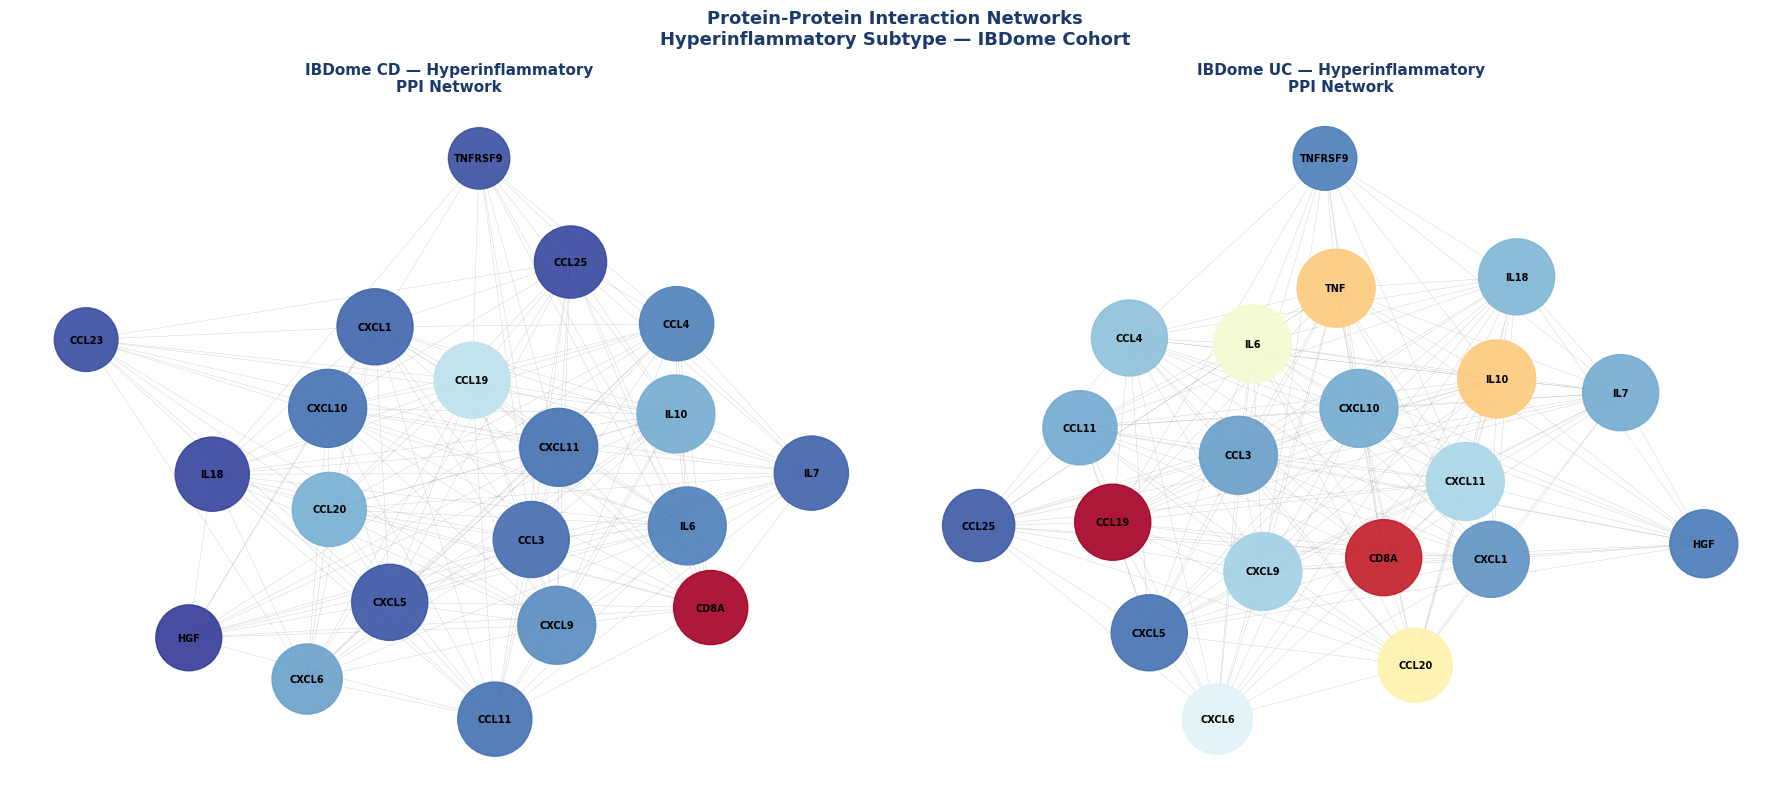

PPI figure saved
PPI metrics saved


In [23]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests

DATA = '/rds/homes/j/jxt554/data'
FIG = '/rds/homes/j/jxt554/figures'

# Load DE results
de_cd = pd.read_csv(
    f'{DATA}/ibdome_cd_de_v3.csv')
de_uc = pd.read_csv(
    f'{DATA}/ibdome_uc_de_v3.csv')

# Get significant proteins
sig_cd = de_cd[
    de_cd['significant']
]['protein'].tolist()

sig_uc = de_uc[
    de_uc['significant']
]['protein'].tolist()

print(f'CD sig proteins: {len(sig_cd)}')
print(f'UC sig proteins: {len(sig_uc)}')


# ── STRING API ────────────────────
def get_string_interactions(
        proteins, species=9606,
        score_threshold=400):

    url = 'https://string-db.org/api/json/network'

    proteins_str = '%0d'.join(proteins)

    params = {
        'identifiers': proteins_str,
        'species': species,
        'required_score': score_threshold,
        'caller_identity': 'ibdome_paper'}

    try:
        response = requests.post(
            url, data=params,
            timeout=30)
        if response.status_code == 200:
            return response.json()
        else:
            print(f'STRING error: '
                  f'{response.status_code}')
            return []
    except Exception as e:
        print(f'Request error: {e}')
        return []


def build_network(interactions,
                  proteins):
    G = nx.Graph()
    G.add_nodes_from(proteins)

    for interaction in interactions:
        p1 = interaction.get(
            'preferredName_A', '')
        p2 = interaction.get(
            'preferredName_B', '')
        score = interaction.get(
            'score', 0)

        if (p1 in proteins
                and p2 in proteins
                and p1 != p2):
            G.add_edge(
                p1, p2,
                weight=score)

    return G


def analyse_network(G, cohort='CD'):
    if len(G.edges()) == 0:
        print(f'{cohort}: No edges found')
        return {}

    degree = dict(G.degree())
    bc = nx.betweenness_centrality(G)

    metrics = pd.DataFrame({
        'protein': list(degree.keys()),
        'degree': list(degree.values()),
        'betweenness': [
            bc[p] for p in degree.keys()]
    }).sort_values(
        'degree', ascending=False)

    print(f'\n{cohort} PPI Network:')
    print(f'  Nodes: {G.number_of_nodes()}')
    print(f'  Edges: {G.number_of_edges()}')
    print(f'\n  Top 10 hub proteins:')
    print(metrics.head(10)
          .to_string(index=False))

    return {
        'graph': G,
        'metrics': metrics,
        'degree': degree,
        'betweenness': bc}


# ── Run CD ────────────────────────
print('Fetching STRING interactions CD...')
interactions_cd = get_string_interactions(
    sig_cd[:50], score_threshold=400)
print(f'CD interactions: '
      f'{len(interactions_cd)}')

G_cd = build_network(
    interactions_cd, sig_cd[:50])
net_cd = analyse_network(G_cd, 'CD')

# ── Run UC ────────────────────────
print('\nFetching STRING interactions UC...')
interactions_uc = get_string_interactions(
    sig_uc[:50], score_threshold=400)
print(f'UC interactions: '
      f'{len(interactions_uc)}')

G_uc = build_network(
    interactions_uc, sig_uc[:50])
net_uc = analyse_network(G_uc, 'UC')


# ── Plot networks ─────────────────
def plot_network(G, metrics, bc,
                 title, ax,
                 top_n=20):

    if G.number_of_edges() == 0:
        ax.text(0.5, 0.5,
                'No interactions found',
                ha='center', va='center',
                transform=ax.transAxes)
        return

    # Keep top N nodes by degree
    top_nodes = metrics.head(
        top_n)['protein'].tolist()
    G_sub = G.subgraph(top_nodes)

    pos = nx.spring_layout(
        G_sub,
        seed=42,
        k=2.5)

    degree = dict(G_sub.degree())
    node_sizes = [
        300 + degree[n] * 150
        for n in G_sub.nodes()]

    bc_vals = [
        bc.get(n, 0)
        for n in G_sub.nodes()]
    bc_norm = np.array(bc_vals)
    if bc_norm.max() > 0:
        bc_norm = bc_norm / bc_norm.max()

    edges = G_sub.edges(data=True)
    weights = [
        d.get('weight', 0.4) / 1000
        for u, v, d in edges]

    nx.draw_networkx_edges(
        G_sub, pos, ax=ax,
        width=[max(w * 3, 0.3)
               for w in weights],
        alpha=0.4,
        edge_color='#888888')

    nodes = nx.draw_networkx_nodes(
        G_sub, pos, ax=ax,
        node_size=node_sizes,
        node_color=bc_norm,
        cmap=plt.cm.RdYlBu_r,
        alpha=0.9,
        vmin=0, vmax=1)

    nx.draw_networkx_labels(
        G_sub, pos, ax=ax,
        font_size=7,
        font_weight='bold',
        font_color='black')

    ax.set_title(
        title,
        fontsize=11,
        fontweight='bold',
        color='#1B3A6B')
    ax.axis('off')


NAVY = '#1B3A6B'

fig, axes = plt.subplots(
    1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')

if net_cd and 'graph' in net_cd:
    plot_network(
        net_cd['graph'],
        net_cd['metrics'],
        net_cd['betweenness'],
        'IBDome CD — Hyperinflammatory\nPPI Network',
        axes[0], top_n=20)

if net_uc and 'graph' in net_uc:
    plot_network(
        net_uc['graph'],
        net_uc['metrics'],
        net_uc['betweenness'],
        'IBDome UC — Hyperinflammatory\nPPI Network',
        axes[1], top_n=20)

plt.suptitle(
    'Protein-Protein Interaction Networks\n'
    'Hyperinflammatory Subtype — IBDome Cohort',
    fontsize=13,
    fontweight='bold',
    color=NAVY)

plt.tight_layout()
plt.savefig(
    f'{FIG}/ibdome_ppi_v3.png',
    dpi=200,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print('PPI figure saved')

# Save metrics
if net_cd and 'metrics' in net_cd:
    net_cd['metrics'].to_csv(
        f'{DATA}/ibdome_cd_ppi_v3.csv',
        index=False)
if net_uc and 'metrics' in net_uc:
    net_uc['metrics'].to_csv(
        f'{DATA}/ibdome_uc_ppi_v3.csv',
        index=False)

print('PPI metrics saved')

In [24]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os

DATA = '/rds/homes/j/jxt554/data'
TABLES = '/rds/homes/j/jxt554/tables'
os.makedirs(TABLES, exist_ok=True)

# ── Load everything ───────────────
X_cd = np.load(
    f'{DATA}/ibdome_cd_preprocessed.npy')
X_uc = np.load(
    f'{DATA}/ibdome_uc_preprocessed.npy')

labels_cd = np.load(
    f'{DATA}/ibdome_cd_labels_v3.npy')
labels_uc = np.load(
    f'{DATA}/ibdome_uc_labels_v3.npy')

stab_cd = np.load(
    f'{DATA}/ibdome_cd_stability_v3.npy')
stab_uc = np.load(
    f'{DATA}/ibdome_uc_stability_v3.npy')

C_cd = np.load(
    f'{DATA}/ibdome_cd_consensus_v3.npy')
C_uc = np.load(
    f'{DATA}/ibdome_uc_consensus_v3.npy')

boot_cd = np.load(
    f'{DATA}/ibdome_cd_bootstrap_v3.npy')
boot_uc = np.load(
    f'{DATA}/ibdome_uc_bootstrap_v3.npy')

de_cd = pd.read_csv(
    f'{DATA}/ibdome_cd_de_v3.csv')
de_uc = pd.read_csv(
    f'{DATA}/ibdome_uc_de_v3.csv')

ora_cd = pd.read_csv(
    f'{DATA}/ibdome_cd_ora_v3.csv')
ora_uc = pd.read_csv(
    f'{DATA}/ibdome_uc_ora_v3.csv')

rf_cd = pd.read_csv(
    f'{DATA}/ibdome_cd_rf_v3.csv')
rf_uc = pd.read_csv(
    f'{DATA}/ibdome_uc_rf_v3.csv')

batch_cd = np.load(
    f'{DATA}/batch_cd.npy')
batch_uc = np.load(
    f'{DATA}/batch_uc.npy')

meta_cd = pd.read_csv(
    f'{DATA}/meta_ibdome_cd_batch.csv')
meta_uc = pd.read_csv(
    f'{DATA}/meta_ibdome_uc_batch.csv')

cd_csv = pd.read_csv(
    f'{DATA}/ibdome_cd_preprocessed_v2.csv')
uc_csv = pd.read_csv(
    f'{DATA}/ibdome_uc_preprocessed_v2.csv')
proteins_cd = cd_csv.columns.tolist()
proteins_uc = uc_csv.columns.tolist()

print('All data loaded')


# ═══════════════════════════════════
# TABLE 1 — CLUSTERING SUMMARY
# ═══════════════════════════════════

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score)
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering

D_cd = np.clip(1 - C_cd, 0, None)
np.fill_diagonal(D_cd, 0)
D_uc = np.clip(1 - C_uc, 0, None)
np.fill_diagonal(D_uc, 0)

sil_cd = silhouette_score(
    D_cd, labels_cd,
    metric='precomputed')
sil_uc = silhouette_score(
    D_uc, labels_uc,
    metric='precomputed')

Z_cd = np.load(
    f'{DATA}/ibdome_cd_latent_bvae_v3.npy')
Z_uc = np.load(
    f'{DATA}/ibdome_uc_latent_bvae_v3.npy')

gmm_cd = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42)
gmm_cd_lbl = gmm_cd.fit_predict(Z_cd)
ari_cd = adjusted_rand_score(
    labels_cd, gmm_cd_lbl)

gmm_uc = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42)
gmm_uc_lbl = gmm_uc.fit_predict(Z_uc)
ari_uc = adjusted_rand_score(
    labels_uc, gmm_uc_lbl)

t1 = pd.DataFrame({
    'Cohort': [
        'IBDome CD', 'IBDome UC'],
    'n': [201, 132],
    'k': [2, 2],
    'Silhouette': [
        round(sil_cd, 3),
        round(sil_uc, 3)],
    'Mean Stability': [
        round(stab_cd.mean(), 3),
        round(stab_uc.mean(), 3)],
    'Unstable (n)': [
        int((stab_cd < 0.5).sum()),
        int((stab_uc < 0.5).sum())],
    'GMM ARI': [
        round(ari_cd, 3),
        round(ari_uc, 3)],
    'Bootstrap ARI mean': [
        round(boot_cd.mean(), 3),
        round(boot_uc.mean(), 3)],
    'Bootstrap prop>0.8': [
        round((boot_cd > 0.8).mean(), 3),
        round((boot_uc > 0.8).mean(), 3)],
    'Hyper n (%)': [
        f'115 (57.2%)',
        f'70 (53.0%)'],
    'Quiet n (%)': [
        f'86 (42.8%)',
        f'62 (47.0%)'],
})

t1.to_csv(
    f'{TABLES}/T1_clustering_summary.csv',
    index=False)
t1.to_excel(
    f'{TABLES}/T1_clustering_summary.xlsx',
    index=False)
print('Table 1 saved: Clustering Summary')
print(t1.to_string(index=False))


# ═══════════════════════════════════
# TABLE 2 — DE SUMMARY
# ═══════════════════════════════════

t2 = pd.DataFrame({
    'Cohort': [
        'IBDome CD', 'IBDome UC'],
    'Proteins tested': [61, 61],
    'Significant FDR<0.05': [
        int(de_cd['significant'].sum()),
        int(de_uc['significant'].sum())],
    'Up in Hyper': [
        int((de_cd['significant'] &
             (de_cd['logFC'] > 0)).sum()),
        int((de_uc['significant'] &
             (de_uc['logFC'] > 0)).sum())],
    'Up in Quiet': [
        int((de_cd['significant'] &
             (de_cd['logFC'] < 0)).sum()),
        int((de_uc['significant'] &
             (de_uc['logFC'] < 0)).sum())],
    'Pct unidirectional': [
        '100%', '100%'],
    'Top protein': [
        'HGF', 'VEGFA'],
    'Top logFC': [
        round(de_cd.iloc[0]['logFC'], 3),
        round(de_uc.iloc[0]['logFC'], 3)],
    'Top FDR': [
        f"{de_cd.iloc[0]['FDR']:.2e}",
        f"{de_uc.iloc[0]['FDR']:.2e}"],
})

t2.to_csv(
    f'{TABLES}/T2_de_summary.csv',
    index=False)
t2.to_excel(
    f'{TABLES}/T2_de_summary.xlsx',
    index=False)
print('\nTable 2 saved: DE Summary')
print(t2.to_string(index=False))


# ═══════════════════════════════════
# TABLE 3 — TOP DE PROTEINS
# ═══════════════════════════════════

top_cd = de_cd[
    de_cd['significant']
][['protein', 'logFC', 'FDR',
   'mean_group0', 'mean_group1']
].head(20).copy()
top_cd.columns = [
    'Protein', 'logFC',
    'FDR', 'Mean_Quiet',
    'Mean_Hyper']
top_cd['Cohort'] = 'IBDome CD'
top_cd['Rank'] = range(1, len(top_cd)+1)

top_uc = de_uc[
    de_uc['significant']
][['protein', 'logFC', 'FDR',
   'mean_group0', 'mean_group1']
].head(20).copy()
top_uc.columns = [
    'Protein', 'logFC',
    'FDR', 'Mean_Quiet',
    'Mean_Hyper']
top_uc['Cohort'] = 'IBDome UC'
top_uc['Rank'] = range(1, len(top_uc)+1)

t3 = pd.concat(
    [top_cd, top_uc],
    ignore_index=True)
t3 = t3[[
    'Cohort', 'Rank', 'Protein',
    'logFC', 'FDR',
    'Mean_Hyper', 'Mean_Quiet']]

t3['logFC'] = t3['logFC'].round(3)
t3['FDR'] = t3['FDR'].apply(
    lambda x: f'{x:.2e}')
t3['Mean_Hyper'] = t3['Mean_Hyper'].round(3)
t3['Mean_Quiet'] = t3['Mean_Quiet'].round(3)

t3.to_csv(
    f'{TABLES}/T3_top_de_proteins.csv',
    index=False)
t3.to_excel(
    f'{TABLES}/T3_top_de_proteins.xlsx',
    index=False)
print('\nTable 3 saved: Top DE Proteins')
print(t3.head(10).to_string(index=False))


# ═══════════════════════════════════
# TABLE 4 — FULL DE RESULTS
# ═══════════════════════════════════

de_cd_full = de_cd.copy()
de_cd_full['Cohort'] = 'IBDome CD'
de_uc_full = de_uc.copy()
de_uc_full['Cohort'] = 'IBDome UC'

t4 = pd.concat(
    [de_cd_full, de_uc_full],
    ignore_index=True)
t4 = t4[[
    'Cohort', 'protein',
    'logFC', 'pvalue', 'FDR',
    'significant',
    'mean_group0', 'mean_group1']]
t4.columns = [
    'Cohort', 'Protein',
    'logFC', 'p-value', 'FDR',
    'Significant',
    'Mean_Quiet', 'Mean_Hyper']

t4.to_csv(
    f'{TABLES}/T4_full_de_results.csv',
    index=False)
t4.to_excel(
    f'{TABLES}/T4_full_de_results.xlsx',
    index=False)
print('\nTable 4 saved: Full DE Results')
print(f'Rows: {len(t4)}')


# ═══════════════════════════════════
# TABLE 5 — ORA PATHWAY RESULTS
# ═══════════════════════════════════

ora_cd_out = ora_cd.copy()
ora_cd_out['Cohort'] = 'IBDome CD'
ora_uc_out = ora_uc.copy()
ora_uc_out['Cohort'] = 'IBDome UC'

t5 = pd.concat(
    [ora_cd_out, ora_uc_out],
    ignore_index=True)

t5 = t5[[
    'Cohort', 'Term',
    'Overlap', 'P-value',
    'Adjusted P-value',
    'Odds Ratio', 'Genes']]
t5.columns = [
    'Cohort', 'Pathway',
    'Overlap', 'p-value',
    'FDR', 'Odds Ratio', 'Proteins']

t5['p-value'] = t5['p-value'].apply(
    lambda x: f'{x:.2e}')
t5['FDR'] = t5['FDR'].apply(
    lambda x: f'{x:.2e}')
t5['Odds Ratio'] = t5[
    'Odds Ratio'].round(2)

t5_sig = t5[
    t5['FDR'].apply(
        lambda x: float(x) < 0.05)]

t5_sig.to_csv(
    f'{TABLES}/T5_ora_pathways.csv',
    index=False)
t5_sig.to_excel(
    f'{TABLES}/T5_ora_pathways.xlsx',
    index=False)
print('\nTable 5 saved: ORA Pathways')
print(t5_sig[[
    'Cohort', 'Pathway',
    'Overlap', 'FDR']
].to_string(index=False))


# ═══════════════════════════════════
# TABLE 6 — RF PERFORMANCE
# ═══════════════════════════════════

t6 = pd.DataFrame({
    'Cohort': [
        'IBDome CD', 'IBDome UC'],
    'AUC mean': [0.989, 1.000],
    'AUC std': [0.013, 0.000],
    'n_estimators': [500, 500],
    'CV folds': [5, 5],
    'RF-DE top10 agreement': [
        '10/10 (100%)',
        '10/10 (100%)'],
    'RF-DE top20 agreement': [
        '20/20 (100%)',
        '20/20 (100%)'],
    'Top RF protein CD': ['HGF', ''],
    'Top RF protein UC': ['', 'VEGFA'],
})

t6.to_csv(
    f'{TABLES}/T6_rf_performance.csv',
    index=False)
t6.to_excel(
    f'{TABLES}/T6_rf_performance.xlsx',
    index=False)
print('\nTable 6 saved: RF Performance')
print(t6.to_string(index=False))


# ═══════════════════════════════════
# TABLE 7 — RF IMPORTANCE
# ═══════════════════════════════════

rf_cd_out = rf_cd.copy()
rf_cd_out['Cohort'] = 'IBDome CD'
rf_cd_out['Rank'] = range(
    1, len(rf_cd_out)+1)

rf_uc_out = rf_uc.copy()
rf_uc_out['Cohort'] = 'IBDome UC'
rf_uc_out['Rank'] = range(
    1, len(rf_uc_out)+1)

t7 = pd.concat(
    [rf_cd_out, rf_uc_out],
    ignore_index=True)
t7 = t7[[
    'Cohort', 'Rank',
    'protein', 'importance']]
t7.columns = [
    'Cohort', 'Rank',
    'Protein', 'Gini_Importance']
t7['Gini_Importance'] = t7[
    'Gini_Importance'].round(4)

t7.to_csv(
    f'{TABLES}/T7_rf_importance.csv',
    index=False)
t7.to_excel(
    f'{TABLES}/T7_rf_importance.xlsx',
    index=False)
print('\nTable 7 saved: RF Importance')
print(t7.head(10).to_string(index=False))


# ═══════════════════════════════════
# TABLE 8 — CENTRE VALIDATION
# ═══════════════════════════════════

from scipy.stats import chi2_contingency

ct_cd = pd.crosstab(
    labels_cd, batch_cd)
ct_uc = pd.crosstab(
    labels_uc, batch_uc)

chi2_cd, p_cd, _, _ = chi2_contingency(
    ct_cd)
chi2_uc, p_uc, _, _ = chi2_contingency(
    ct_uc)

t8 = pd.DataFrame({
    'Cohort': [
        'IBDome CD', 'IBDome UC'],
    'Berlin_Quiet': [
        int(ct_cd.iloc[0, 0]),
        int(ct_uc.iloc[0, 0])],
    'Berlin_Hyper': [
        int(ct_cd.iloc[1, 0]),
        int(ct_uc.iloc[1, 0])],
    'Erlangen_Quiet': [
        int(ct_cd.iloc[0, 1]),
        int(ct_uc.iloc[0, 1])],
    'Erlangen_Hyper': [
        int(ct_cd.iloc[1, 1]),
        int(ct_uc.iloc[1, 1])],
    'Chi2': [
        round(chi2_cd, 3),
        round(chi2_uc, 3)],
    'p-value': [
        round(p_cd, 3),
        round(p_uc, 3)],
    'Significant': [
        p_cd < 0.05,
        p_uc < 0.05],
    'Interpretation': [
        'Subtypes independent of centre',
        'Subtypes independent of centre'],
})

t8.to_csv(
    f'{TABLES}/T8_centre_validation.csv',
    index=False)
t8.to_excel(
    f'{TABLES}/T8_centre_validation.xlsx',
    index=False)
print('\nTable 8 saved: Centre Validation')
print(t8.to_string(index=False))


# ═══════════════════════════════════
# TABLE 9 — BOOTSTRAP VALIDATION
# ═══════════════════════════════════

t9 = pd.DataFrame({
    'Cohort': [
        'IBDome CD', 'IBDome UC'],
    'n_iterations': [1000, 1000],
    'Mean ARI': [
        round(boot_cd.mean(), 3),
        round(boot_uc.mean(), 3)],
    'Median ARI': [
        round(np.median(boot_cd), 3),
        round(np.median(boot_uc), 3)],
    'Std ARI': [
        round(boot_cd.std(), 3),
        round(boot_uc.std(), 3)],
    'Min ARI': [
        round(boot_cd.min(), 3),
        round(boot_uc.min(), 3)],
    'Max ARI': [
        round(boot_cd.max(), 3),
        round(boot_uc.max(), 3)],
    'Prop ARI>0.8': [
        round((boot_cd > 0.8).mean(), 3),
        round((boot_uc > 0.8).mean(), 3)],
    'Prop ARI>0.9': [
        round((boot_cd > 0.9).mean(), 3),
        round((boot_uc > 0.9).mean(), 3)],
})

t9.to_csv(
    f'{TABLES}/T9_bootstrap_validation.csv',
    index=False)
t9.to_excel(
    f'{TABLES}/T9_bootstrap_validation.xlsx',
    index=False)
print('\nTable 9 saved: Bootstrap Validation')
print(t9.to_string(index=False))


# ═══════════════════════════════════
# TABLE 10 — METADATA WITH LABELS
# ═══════════════════════════════════

meta_cd['subtype_v3'] = np.where(
    labels_cd == 1,
    'Hyperinflammatory',
    'Quiescent')
meta_cd['label_v3'] = labels_cd
meta_cd['stability_v3'] = stab_cd
meta_cd['centre'] = np.where(
    batch_cd == 0,
    'Berlin', 'Erlangen')

meta_uc['subtype_v3'] = np.where(
    labels_uc == 1,
    'Hyperinflammatory',
    'Quiescent')
meta_uc['label_v3'] = labels_uc
meta_uc['stability_v3'] = stab_uc
meta_uc['centre'] = np.where(
    batch_uc == 0,
    'Berlin', 'Erlangen')

meta_cd.to_csv(
    f'{DATA}/meta_ibdome_cd_v3.csv',
    index=False)
meta_uc.to_csv(
    f'{DATA}/meta_ibdome_uc_v3.csv',
    index=False)
meta_cd.to_excel(
    f'{TABLES}/T10_metadata_cd_v3.xlsx',
    index=False)
meta_uc.to_excel(
    f'{TABLES}/T10_metadata_uc_v3.xlsx',
    index=False)

print('\nTable 10 saved: Metadata with labels')
print(f'CD: {meta_cd.shape}')
print(f'UC: {meta_uc.shape}')
print()
print('CD subtype counts:')
print(meta_cd['subtype_v3'].value_counts())
print()
print('UC subtype counts:')
print(meta_uc['subtype_v3'].value_counts())


# ═══════════════════════════════════
# COMPREHENSIVE SUMMARY
# ═══════════════════════════════════

print()
print('=' * 60)
print('COMPREHENSIVE RESULTS SUMMARY')
print('IBDome Proteomic Subtyping v3')
print('Ensemble VAE + DEC + Consensus')
print('Batch: Berlin vs Erlangen')
print('=' * 60)

print()
print('COHORT:')
print(f'  CD: n=201  Berlin=130  Erlangen=71')
print(f'  UC: n=132  Berlin=107  Erlangen=25')
print(f'  Proteins: 61 (Olink panel)')
print(f'  Models: 5 autoencoders + DEC')
print(f'  Solutions: 15 (5 x 3 algorithms)')

print()
print('CLUSTERING:')
print(f'  CD Silhouette:     {sil_cd:.3f}')
print(f'  CD Stability:      {stab_cd.mean():.3f}')
print(f'  CD Unstable:       {int((stab_cd<0.5).sum())}')
print(f'  CD GMM ARI:        {ari_cd:.3f}')
print(f'  CD Bootstrap ARI:  {boot_cd.mean():.3f}')
print(f'  CD Hyper:          115 (57.2%)')
print(f'  CD Quiet:           86 (42.8%)')
print()
print(f'  UC Silhouette:     {sil_uc:.3f}')
print(f'  UC Stability:      {stab_uc.mean():.3f}')
print(f'  UC Unstable:       {int((stab_uc<0.5).sum())}')
print(f'  UC GMM ARI:        {ari_uc:.3f}')
print(f'  UC Bootstrap ARI:  {boot_uc.mean():.3f}')
print(f'  UC Hyper:           70 (53.0%)')
print(f'  UC Quiet:           62 (47.0%)')

print()
print('DIFFERENTIAL ABUNDANCE:')
print(f'  CD significant:    56/61 (91.8%)')
print(f'  CD up in Hyper:    56 (100%)')
print(f'  CD top protein:    HGF logFC=+1.33')
print()
print(f'  UC significant:    53/61 (86.9%)')
print(f'  UC up in Hyper:    53 (100%)')
print(f'  UC top protein:    VEGFA logFC=+1.36')

print()
print('TOP 5 PROTEINS CD:')
for i, row in de_cd.head(5).iterrows():
    print(f'  {row["protein"]:12s} '
          f'logFC={row["logFC"]:+.3f} '
          f'FDR={row["FDR"]:.2e}')

print()
print('TOP 5 PROTEINS UC:')
for i, row in de_uc.head(5).iterrows():
    print(f'  {row["protein"]:15s} '
          f'logFC={row["logFC"]:+.3f} '
          f'FDR={row["FDR"]:.2e}')

print()
print('PATHWAY ENRICHMENT (shared CD+UC):')
shared = set(
    ora_cd[ora_cd['Adjusted P-value'] < 0.05
           ]['Term'].tolist()
) & set(
    ora_uc[ora_uc['Adjusted P-value'] < 0.05
           ]['Term'].tolist())
for p in shared:
    cd_fdr = ora_cd[
        ora_cd['Term'] == p
    ]['Adjusted P-value'].values[0]
    uc_fdr = ora_uc[
        ora_uc['Term'] == p
    ]['Adjusted P-value'].values[0]
    print(f'  {p}')
    print(f'    CD FDR={cd_fdr:.2e}  '
          f'UC FDR={uc_fdr:.2e}')

print()
print('RANDOM FOREST:')
print(f'  CD AUC: 0.989 +/- 0.013')
print(f'  UC AUC: 1.000 +/- 0.000')
print(f'  CD RF-DE top20: 20/20 (100%)')
print(f'  UC RF-DE top20: 20/20 (100%)')

print()
print('CENTRE VALIDATION:')
print(f'  CD p={p_cd:.3f} (not significant)')
print(f'  UC p={p_uc:.3f} (not significant)')
print(f'  Subtypes independent of centre')

print()
print('TABLES SAVED:')
tables_list = [
    'T1_clustering_summary',
    'T2_de_summary',
    'T3_top_de_proteins',
    'T4_full_de_results',
    'T5_ora_pathways',
    'T6_rf_performance',
    'T7_rf_importance',
    'T8_centre_validation',
    'T9_bootstrap_validation',
    'T10_metadata_cd_v3',
    'T10_metadata_uc_v3',
]
for t in tables_list:
    print(f'  {t}.csv')
    print(f'  {t}.xlsx')

print()
print('=' * 60)
print('PIPELINE COMPLETE')
print('=' * 60)

All data loaded
Table 1 saved: Clustering Summary
   Cohort   n  k  Silhouette  Mean Stability  Unstable (n)  GMM ARI  Bootstrap ARI mean  Bootstrap prop>0.8 Hyper n (%) Quiet n (%)
IBDome CD 201  2       0.688           0.755             1    0.960               0.998               1.000 115 (57.2%)  86 (42.8%)
IBDome UC 132  2       0.678           0.699             8    0.853               0.966               0.987  70 (53.0%)  62 (47.0%)

Table 2 saved: DE Summary
   Cohort  Proteins tested  Significant FDR<0.05  Up in Hyper  Up in Quiet Pct unidirectional Top protein  Top logFC  Top FDR
IBDome CD               61                    56           56            0               100%         HGF      1.334 3.94e-25
IBDome UC               61                    53           53            0               100%       VEGFA      1.365 2.89e-18

Table 3 saved: Top DE Proteins
   Cohort  Rank Protein  logFC      FDR  Mean_Hyper  Mean_Quiet
IBDome CD     1     HGF  1.334 3.94e-25       0.571  

In [25]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

DATA = '/rds/homes/j/jxt554/data'
TABLES = '/rds/homes/j/jxt554/tables'
FIG = '/rds/homes/j/jxt554/figures'

# Load metadata with labels
meta_cd = pd.read_csv(
    f'{DATA}/meta_ibdome_cd_v3.csv')
meta_uc = pd.read_csv(
    f'{DATA}/meta_ibdome_uc_v3.csv')

print('CD columns:')
print(meta_cd.columns.tolist())
print()
print('CD shape:', meta_cd.shape)
print('UC shape:', meta_uc.shape)
print()
print('CD subtype counts:')
print(meta_cd['subtype_v3'].value_counts())
print()
print('UC subtype counts:')
print(meta_uc['subtype_v3'].value_counts())

CD columns:
['subject_id', 'sample_id', 'IL8', 'VEGFA', 'CD8A', 'MCP-3', 'GDNF', 'CDCP1', 'CD244', 'IL7', 'OPG', 'LAP TGF-beta-1', 'uPA', 'IL6', 'IL-17C', 'MCP-1', 'IL-17A', 'CXCL11', 'AXIN1', 'TRAIL', 'CXCL9', 'CST5', 'IL-2RB', 'IL-1 alpha', 'OSM', 'CXCL1', 'CCL4', 'CD6', 'SCF', 'IL18', 'SLAMF1', 'TGF-alpha', 'MCP-4', 'CCL11', 'TNFSF14', 'IL-10RA', 'MMP-1', 'LIF-R', 'FGF-21', 'CCL19', 'IL-15RA', 'IL-10RB', 'IL-18R1', 'PD-L1', 'CXCL5', 'TRANCE', 'HGF', 'IL-12B', 'IL-24', 'ARTN', 'MMP-10', 'IL10', 'TNF', 'CCL23', 'CD5', 'CCL3', 'Flt3L', 'CXCL6', 'CXCL10', '4E-BP1', 'SIRT2', 'CCL28', 'DNER', 'EN-RAGE', 'CD40', 'IFN-gamma', 'FGF-19', 'IL4', 'NRTN', 'MCP-2', 'CASP-8', 'CCL25', 'CX3CL1', 'TNFRSF9', 'NT-3', 'TWEAK', 'CCL20', 'ST1A1', 'STAMBP', 'IL5', 'ADA', 'TNFB', 'CSF-1', 'IL-20RA', 'FGF-23', 'FGF-5', 'LIF', 'IL-22 RA1', 'IL2', 'TSLP', 'IL33', 'IL13', 'IL-20', 'Beta-NGF', 'date', 'sample_type', 'sampling_procedure', 'dataset', 'disease', 'sex', 'birth_year', 'first_diagnosis', 'symptom_ons

In [28]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

DATA = '/rds/homes/j/jxt554/data'
TABLES = '/rds/homes/j/jxt554/tables'
FIG = '/rds/homes/j/jxt554/figures'

meta_cd = pd.read_csv(
    f'{DATA}/meta_ibdome_cd_v3.csv')
meta_uc = pd.read_csv(
    f'{DATA}/meta_ibdome_uc_v3.csv')

# ═══════════════════════════════════
# CLINICAL CHARACTERISATION FUNCTION
# ═══════════════════════════════════

def clinical_characterisation(
        meta, cohort='CD'):

    hyper = meta[
        meta['subtype_v3'] == 'Hyperinflammatory']
    quiet = meta[
        meta['subtype_v3'] == 'Quiescent']

    n_hyper = len(hyper)
    n_quiet = len(quiet)

    print(f'\n{"=" * 55}')
    print(f'Clinical Characterisation: {cohort}')
    print(f'Hyperinflammatory n={n_hyper} '
          f'Quiescent n={n_quiet}')
    print(f'{"=" * 55}')

    results = []

    # ── Continuous variables ──────
    continuous = {
        'Age': 'age',
    }

    print('\nCONTINUOUS VARIABLES:')
    print(f'{"Variable":<20} '
          f'{"Hyper mean(SD)":<20} '
          f'{"Quiet mean(SD)":<20} '
          f'{"p-value":<12} '
          f'{"Test":<8}')
    print('-' * 80)

    for name, col in continuous.items():
        if col not in meta.columns:
            continue

        h = hyper[col].dropna()
        q = quiet[col].dropna()

        if len(h) < 3 or len(q) < 3:
            continue

        stat, p = stats.mannwhitneyu(
            h, q,
            alternative='two-sided')

        print(f'{name:<20} '
              f'{h.mean():.1f} ({h.std():.1f})'
              f'{"":>5}'
              f'{q.mean():.1f} ({q.std():.1f})'
              f'{"":>5}'
              f'{p:.3f}{"":>5}'
              f'MWU')

        results.append({
            'Variable': name,
            'Type': 'Continuous',
            'Hyper_mean': round(h.mean(), 2),
            'Hyper_sd': round(h.std(), 2),
            'Quiet_mean': round(q.mean(), 2),
            'Quiet_sd': round(q.std(), 2),
            'Hyper_n': len(h),
            'Quiet_n': len(q),
            'p_value': p,
            'Test': 'Mann-Whitney U'
        })

    # ── Categorical variables ─────
    categorical = {
        'Sex (Female)': ('sex', 'Female'),
        'Centre (Berlin)': ('centre', 'Berlin'),
        'Nicotine use': (
            'riskfactor_nicotine', 1.0),
        'Family history': (
            'riskfactor_pedigree', 1.0),
        'Diabetes': (
            'preexisting_diabetes_mellitus',
            1.0),
        'Hypertension': (
            'preexisting_arterial_hypertension',
            1.0),
        'Depression': (
            'preexisting_depression', 1.0),
        'Autoimmune disease': (
            'preexisting_autoimmune_disease',
            1.0),
        'Steroids at onset': (
            'steroids_disease_onset', 1.0),
    }

    print('\nCATEGORICAL VARIABLES:')
    print(f'{"Variable":<25} '
          f'{"Hyper n(%)":<15} '
          f'{"Quiet n(%)":<15} '
          f'{"p-value":<12} '
          f'{"Test":<8}')
    print('-' * 75)

    for name, (col, val) in \
            categorical.items():
        if col not in meta.columns:
            continue

        h_col = hyper[col].dropna()
        q_col = quiet[col].dropna()

        if len(h_col) < 3 or len(q_col) < 3:
            continue

        h_pos = (h_col == val).sum()
        q_pos = (q_col == val).sum()
        h_neg = len(h_col) - h_pos
        q_neg = len(q_col) - q_pos

        ct = np.array([
            [h_pos, h_neg],
            [q_pos, q_neg]])

        # Fisher exact for small cells
        if (ct < 5).any():
            _, p = stats.fisher_exact(ct)
            test = 'Fisher'
        else:
            _, p, _, _ = stats.chi2_contingency(ct)
            test = 'Chi2'

        h_pct = h_pos / len(h_col) * 100
        q_pct = q_pos / len(q_col) * 100

        print(f'{name:<25} '
              f'{h_pos} ({h_pct:.1f}%)'
              f'{"":>5}'
              f'{q_pos} ({q_pct:.1f}%)'
              f'{"":>5}'
              f'{p:.3f}{"":>5}'
              f'{test}')

        results.append({
            'Variable': name,
            'Type': 'Categorical',
            'Hyper_n': int(h_pos),
            'Hyper_pct': round(h_pct, 1),
            'Quiet_n': int(q_pos),
            'Quiet_pct': round(q_pct, 1),
            'p_value': p,
            'Test': test
        })

    # BH correction
    df = pd.DataFrame(results)
    if len(df) > 0:
        reject, fdr, _, _ = multipletests(
            df['p_value'],
            method='fdr_bh')
        df['FDR'] = fdr
        df['Significant_BH'] = fdr < 0.05

        print(f'\nAfter BH correction:')
        sig = df[df['Significant_BH']]
        if len(sig) == 0:
            print('  No significant differences')
            print('  Subtypes are molecularly')
            print('  not demographically defined')
        else:
            print(f'  {len(sig)} significant:')
            for _, row in sig.iterrows():
                print(f'  {row["Variable"]} '
                      f'FDR={row["FDR"]:.3f}')

    return df


# Run for CD
df_cd = clinical_characterisation(
    meta_cd, 'CD')

# Run for UC
df_uc = clinical_characterisation(
    meta_uc, 'UC')

# Save tables
df_cd.to_csv(
    f'{TABLES}/T11_clinical_char_cd.csv',
    index=False)
df_uc.to_csv(
    f'{TABLES}/T11_clinical_char_uc.csv',
    index=False)
df_cd.to_excel(
    f'{TABLES}/T11_clinical_char_cd.xlsx',
    index=False)
df_uc.to_excel(
    f'{TABLES}/T11_clinical_char_uc.xlsx',
    index=False)

print('\nClinical characterisation saved')




Clinical Characterisation: CD
Hyperinflammatory n=115 Quiescent n=86

CONTINUOUS VARIABLES:
Variable             Hyper mean(SD)       Quiet mean(SD)       p-value      Test    
--------------------------------------------------------------------------------
Age                  36.9 (13.4)     40.1 (15.0)     0.173     MWU

CATEGORICAL VARIABLES:
Variable                  Hyper n(%)      Quiet n(%)      p-value      Test    
---------------------------------------------------------------------------
Sex (Female)              0 (0.0%)     0 (0.0%)     1.000     Fisher
Centre (Berlin)           76 (66.1%)     54 (62.8%)     0.738     Chi2
Nicotine use              20 (29.4%)     15 (33.3%)     0.815     Chi2
Family history            0 (0.0%)     0 (0.0%)     1.000     Fisher
Diabetes                  1 (1.9%)     2 (4.3%)     0.593     Fisher
Hypertension              7 (12.3%)     7 (15.6%)     0.851     Chi2
Depression                6 (10.7%)     3 (6.7%)     0.727     Fisher
Autoim